# FunctionTransformer: Custom Logical Wrapping 🛠️

In Scikit-Learn, the **`FunctionTransformer`** is a bridge that allows you to take any custom Python function and turn it into an official Scikit-Learn "Transformer."

---

## 🧠 The Concept: Why use it?
Usually, we use pre-built tools like `StandardScaler` or `OneHotEncoder`. But real-world data science often requires custom math, such as **Log Transformations**, **Square Roots**, or **Unit Conversions**.

By wrapping your custom function in a `FunctionTransformer`, you ensure it can be included in a Scikit-Learn **Pipeline**, making your entire workflow automated and reproducible.

---

## 🛠️ Implementation Example

The most common use case is for **Log Transformation** to handle skewed data:

```python
import numpy as np
from sklearn.preprocessing import FunctionTransformer

# 1. Define your custom logic
# np.log1p (log + 1) is safer for data containing zeroes
def log_transform(x):
    return np.log1p(x)

# 2. Wrap it in a FunctionTransformer
transformer = FunctionTransformer(log_transform)

# 3. Use it just like a normal Scaler
dataset_clean['Fare_Logged'] = transformer.fit_transform(dataset_clean[['Fare']])
```

---

## 🎨 When to use it?

### 1. Log Transformation
To "squash" heavily skewed data (like Salary or Fares) so the model can see patterns more clearly.

### 2. Custom Mathematical Scaling
If you need to divide a column by a specific value (e.g., converting "Minutes" into "Hours") or square a feature ($Age \times Age$) to capture non-linear trends.

### 3. Cleaning Operations
Any custom cleaning step (like stripping whitespace or complex string mapping) that you want to perform consistently across training and test data.

---

## ⚖️ Comparison: Standard vs. Custom

| Feature | Standard Transformer | FunctionTransformer |
| :--- | :--- | :--- |
| **Logic** | Pre-built (Standard, Min-Max) | **Your Custom Python Code** |
| **Goal** | General Scaling | **Specific Math Operations** |
| **Pipeline Integration** | Yes | **Yes (The primary benefit)** |

> [!TIP]
> Use `np.log1p()` instead of `np.log()` inside your transformer. If your data contains even a single zero, a normal log will return `-inf` and crash your model, but `log1p` handles it safely!


### Test

In [1]:
print("hello world")

hello world


### Importing Libs & data

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [15]:
dataset = pd.read_csv("../data/messy_ml_data.csv")
dataset.head(3)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,52.0,104.22,F,Tokyo,Free,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,15.0,30.03,F,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10


In [16]:
dataset.shape

(761, 14)

### Check for duplicates

In [17]:
# 1. Count the exact duplicates
print(f"Total duplicate rows: {dataset.duplicated().sum()}")

Total duplicate rows: 0


In [25]:
# 2. See the exact duplicates
dataset[dataset.duplicated()]

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode


In [19]:
# 3. Drop the exact duplicates
dataset.drop_duplicates().head(3)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,52.0,104.22,F,Tokyo,Free,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,15.0,30.03,F,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10


In [26]:
# Checks for duplicates based on everything EXCEPT PassengerId - semantic duplicates
dataset.duplicated(subset=dataset.columns.difference(['PassengerId'])).sum()

np.int64(0)

In [21]:
dataset[dataset.duplicated(subset=dataset.columns.difference(['PassengerId']))]

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
752,753,9.0,38.34,F,Tokyo,Premium,86.0,2021-05-17,user502@example.com,+1-555-6157,1,Average,D01,NaN
755,756,63.0,25.94,F,London,Premium,59.0,2021-10-11,user649@example.com,+1-555-4478,No,Good,D01,NaN
756,757,60.0,67.70,male,New York,Basic,70.0,2020-12-06,user340@example.com,+1-555-2234,1,ok,D02,NaN
757,758,57.0,450.79,male,New York,Basic,82.0,2020-05-27,user147@example.com,+1-555-8248,0,ok,D03,NaN


In [22]:
# 1. Define the columns that we want to check for duplicates
# (This excludes PassengerId from the check)
search_cols = dataset.columns.difference(['PassengerId'])

# 2. Use drop_duplicates to remove them
# keep='first' means we keep the original row and delete the second copy
dataset = dataset.drop_duplicates(subset=search_cols, keep='first')

# 3. Reset the index (Best practice after dropping rows)
dataset = dataset.reset_index(drop=True)

# 4. Verify they are gone!
print(f"New row count: {len(dataset)}")
print(f"Remaining Semantic Duplicates: {dataset.duplicated(subset=search_cols).sum()}")

New row count: 757
Remaining Semantic Duplicates: 0


### Handling Missing values

In [23]:
dataset.isnull().sum()

PassengerId       0
Age              16
Fare             25
Gender           23
City             21
Subscription     26
Score            16
JoinDate         20
Email            12
Phone            26
IsActive         21
Remarks          26
DeptCode         21
DiscountCode    458
dtype: int64

In [24]:
# 1. Fill Age with Median (Robust against the 200-year-olds)
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
# 2. Fill Fare with Median (Robust against expensive outliers)
dataset['Fare'] = dataset['Fare'].fillna(dataset['Fare'].median())
# 3. Fill Score with Median (Standard Safe choice)
dataset['Score'] = dataset['Score'].fillna(dataset['Score'].median())
# 4. Verify all nulls are gone
print(dataset[['Age', 'Fare', 'Score']].isnull().sum())

Age      0
Fare     0
Score    0
dtype: int64


### Removing outliers

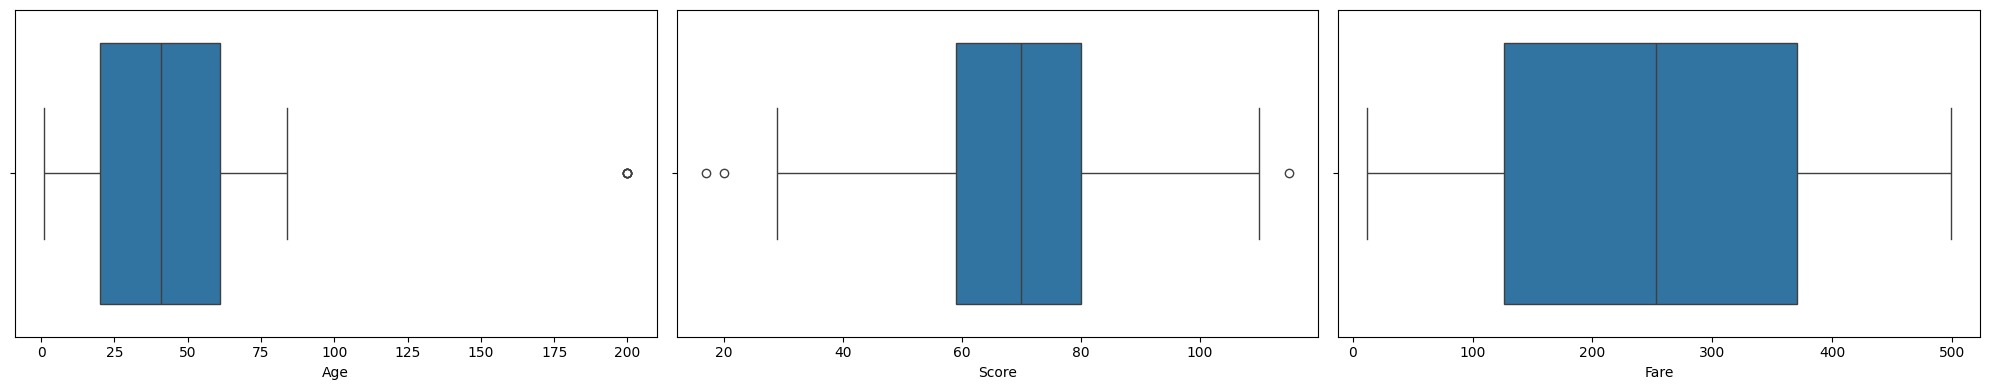

In [31]:
plt.figure(figsize=(20,4))
plt.subplot(1,3,1)
sns.boxplot(x='Age', data=dataset)
plt.subplot(1,3,2)
sns.boxplot(x='Score', data=dataset)
plt.subplot(1,3,3)
sns.boxplot(x='Fare', data=dataset)

plt.tight_layout() # Ensures the plots don't overlap
plt.show() # Only call show at the VERY END

In [32]:
# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the DataFrame
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [33]:
# Apply to each column sequentially
dataset_clean = remove_outliers(dataset, 'Age')
dataset_clean = remove_outliers(dataset_clean, 'Fare')
dataset_clean = remove_outliers(dataset_clean, 'Score')
# 4. Verify the results
print(f"Original Dataset Size: {len(dataset)}")
print(f"Cleaned Dataset Size: {len(dataset_clean)}")
print(f"Total Rows Removed: {len(dataset) - len(dataset_clean)}")

Original Dataset Size: 757
Cleaned Dataset Size: 749
Total Rows Removed: 8


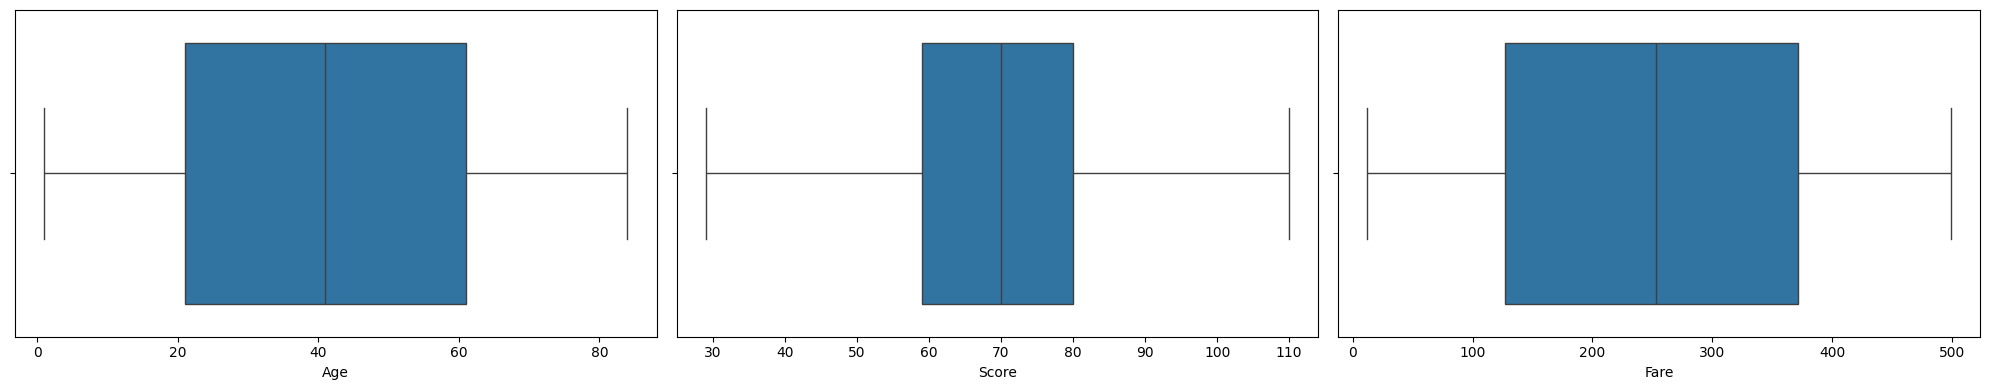

In [34]:
plt.figure(figsize=(20,4))
plt.subplot(1,3,1)
sns.boxplot(x='Age', data=dataset_clean)
plt.subplot(1,3,2)
sns.boxplot(x='Score', data=dataset_clean)
plt.subplot(1,3,3)
sns.boxplot(x='Fare', data=dataset_clean)

plt.tight_layout() # Ensures the plots don't overlap
plt.show() # Only call show at the VERY END

# Function Transformer

In [48]:
from sklearn.preprocessing import FunctionTransformer

In [49]:
# 1. Define your custom logic (e.g., Log Transformation)
# np.log1p is safe because it handles log(0) by adding 1 first
def my_log_transform(x):
    return np.log1p(x)

In [50]:
# 2. Wrap it in a FunctionTransformer
log_transformer = FunctionTransformer(my_log_transform)

In [51]:
# 3. Use it just like a normal Scaler
cols_to_scale = ['Age', 'Fare', 'Score']
ar = log_transformer.fit_transform(dataset_clean[cols_to_scale])
ar, dataset_clean[cols_to_scale]

(          Age      Fare     Score
 0    3.970292  4.656053  4.025352
 1    2.772589  3.434954  4.418841
 2    4.290459  4.540952  4.510860
 3    4.127134  4.993896  4.477337
 4    3.091042  4.582311  4.304065
 ..        ...       ...       ...
 752  2.564949  4.814864  4.143135
 753  2.397895  5.494542  4.007333
 754  2.302585  5.772686  4.077537
 755  3.951244  5.439079  4.127134
 756  2.995732  5.824110  4.094345
 
 [749 rows x 3 columns],
       Age    Fare  Score
 0    52.0  104.22   55.0
 1    15.0   30.03   82.0
 2    72.0   92.78   90.0
 3    61.0  146.51   87.0
 4    21.0   96.74   73.0
 ..    ...     ...    ...
 752  12.0  122.33   62.0
 753  10.0  242.36   54.0
 754   9.0  320.40   58.0
 755  51.0  229.23   61.0
 756  19.0  337.36   59.0
 
 [749 rows x 3 columns])

In [67]:
dataset_clean_normalized=dataset_clean.copy() 
dataset_clean_normalized[cols_to_scale] = ar
dataset_clean_normalized.head(3)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,3.970292,4.656053,F,Tokyo,Free,4.025352,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,2.772589,3.434954,F,London,Premium,4.418841,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,4.290459,4.540952,Female,New York,Basic,4.510860,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10


In [68]:
def plot_soft_distribution(df, column):
    # 1. Calculate the data range programmatically
    data_min = df[column].min()
    data_max = df[column].max()
    data_range = data_max - data_min
    
    # 2. Add 15% padding to the sides (The "Screenshot" Effect)
    # This replaces the hardcoded -20 and 100
    p_lower = data_min - (data_range * 0.3)
    p_upper = data_max + (data_range * 0.3)
    
    # 3. Create the plot with "soft" styling (no outlines)
    sns.histplot(df[column], 
                 kde=True, 
                 stat='density', 
                 linewidth=0,      # Removes black outlines
                 kde_kws={'cut': 5}) # Allows the line to trail off
    
    # 4. Set the dynamic limits
    plt.xlim(p_lower, p_upper)
    plt.title(f'{column} distribution')
    # plt.show()

# --- Now it works for any data! ---
# plot_soft_distribution(dataset_clean, 'Age')

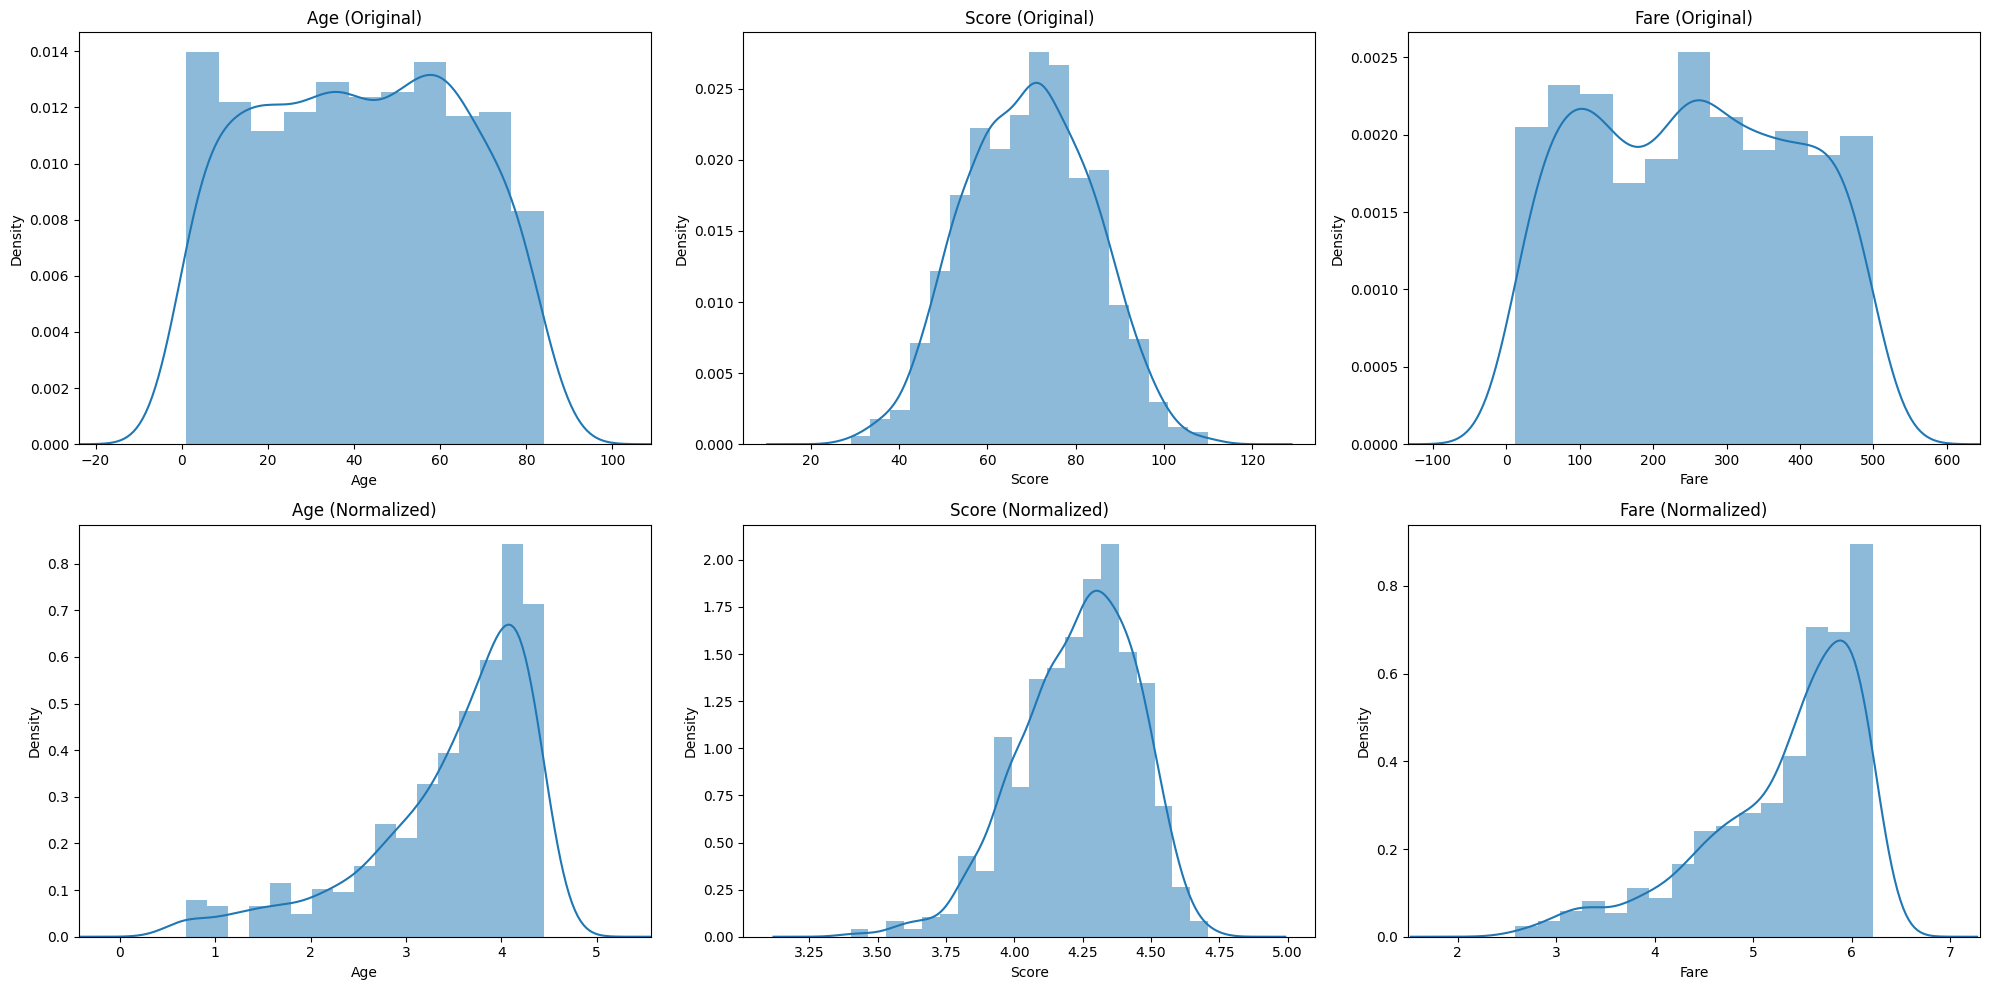

In [70]:
import matplotlib.pyplot as plt

# Increase figsize height to accommodate 2 rows
plt.figure(figsize=(20, 10))

# --- ROW 1: ORIGINAL DATA ---
plt.subplot(2, 3, 1)
plot_soft_distribution(dataset_clean, 'Age')
plt.title('Age (Original)')

plt.subplot(2, 3, 2)
plot_soft_distribution(dataset_clean, 'Score')
plt.title('Score (Original)')

plt.subplot(2, 3, 3)
plot_soft_distribution(dataset_clean, 'Fare')
plt.title('Fare (Original)')

# --- ROW 2: NORMALIZED DATA ---
plt.subplot(2, 3, 4)
plot_soft_distribution(dataset_clean_normalized, 'Age')
plt.title('Age (Normalized)')

plt.subplot(2, 3, 5)
plot_soft_distribution(dataset_clean_normalized, 'Score')
plt.title('Score (Normalized)')

plt.subplot(2, 3, 6)
plot_soft_distribution(dataset_clean_normalized, 'Fare')
plt.title('Fare (Normalized)')

plt.tight_layout()
plt.show()


In [43]:
def hundredTimes(x):
    y = x*100
    return y

In [45]:
log_transformer1 = FunctionTransformer(hundredTimes)
cols_to_scale = ['Age', 'Fare', 'Score']
ar = log_transformer1.fit_transform(dataset_clean[cols_to_scale])
ar, dataset_clean[cols_to_scale]

(        Age     Fare   Score
 0    5200.0  10422.0  5500.0
 1    1500.0   3003.0  8200.0
 2    7200.0   9278.0  9000.0
 3    6100.0  14651.0  8700.0
 4    2100.0   9674.0  7300.0
 ..      ...      ...     ...
 752  1200.0  12233.0  6200.0
 753  1000.0  24236.0  5400.0
 754   900.0  32040.0  5800.0
 755  5100.0  22923.0  6100.0
 756  1900.0  33736.0  5900.0
 
 [749 rows x 3 columns],
       Age    Fare  Score
 0    52.0  104.22   55.0
 1    15.0   30.03   82.0
 2    72.0   92.78   90.0
 3    61.0  146.51   87.0
 4    21.0   96.74   73.0
 ..    ...     ...    ...
 752  12.0  122.33   62.0
 753  10.0  242.36   54.0
 754   9.0  320.40   58.0
 755  51.0  229.23   61.0
 756  19.0  337.36   59.0
 
 [749 rows x 3 columns])

# It was not scaled it was log transformed .... so was it normalized ? or was it scaled ? or something totally else ?


# Transformation vs. Scaling: What's the Difference? 🔄⚖️

It is easy to confuse **Data Transformation** (like Log) with **Feature Scaling** (like Min-Max). While both change your numbers, they serve two very different mathematical goals.

---

## 1. Data Transformation (e.g., Log, Square Root)
*   **Target**: The **SHAPE** of the distribution.
*   **What it does**: It mathematically alters the relationships between points to "pull in" extreme tails.
*   **The Goal**: To turn **Skewed Data** (lopsided) into **Normal Data** (Bell Curve).
*   **Result**: If your Fare was `[10, 100, 1000]`, a Log Transform turns it into `[2.3, 4.6, 6.9]`. The "Exponential" gap is gone, but the range is not squashed into a specific 0-1 box yet.

---

## 2. Feature Scaling (e.g., Normalization, Standardization)
*   **Target**: The **RANGE** of the data.
*   **What it does**: It shifts and squashes the numbers without changing the underlying "shape" of the curve.
*   **The Goal**: To ensure features with massive numbers (like Salary) don't unfairly dominate smaller ones (like Age).
*   **Result**: If your data is lopsided, after scaling, it is **still lopsided**—just with smaller numbers (like 0 to 1).

---

## 📊 Comparison Summary

| Method | Changes the **Shape**? | Changes the **Range**? | Primary Use Case |
| :--- | :--- | :--- | :--- |
| **Log Transform** | **Yes** (Fixes Skew) | Yes (Math side-effect) | Handling heavy "Tails" (Fares/Income). |
| **Normalization** | No | **Yes** (0 to 1) | Equalizing different units (Meters vs Miles). |
| **Standardization** | No | **Yes** (Mean=0) | Prep for Linear/Distance models (SVM, KNN). |

---

## 🏆 The "Double-Cleaned" Strategy
In professional Data Science pipelines, we often use both in a specific sequence:
1.  **Transform First**: Use **Log Transformation** to fix the "Ugly" skewed shape of your column.
2.  **Scale Second**: Use **Standardization** or **Normalization** to bring that new "balanced" shape into the same range as your other features.

> [!IMPORTANT]
> A Log Transformation is **not** a scaler! After logging your data, you should still apply a Scaler so that your `Fare_Logged` is on the same playing field as your `Age` and `Score`.
